In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import * 
from sklearn.linear_model import *
from sklearn.metrics import *
from sklearn.metrics import *

In [2]:
df = pd.read_csv('C:\\Users\\newbl\\OneDrive\\Desktop\\Exam score predictor\\data\\student_exam_scores.csv')
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [4]:
df.isnull().sum()

student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

In [5]:
df.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [6]:
df["exam_score"].describe()

count    200.000000
mean      33.955000
std        6.789548
min       17.100000
25%       29.500000
50%       34.050000
75%       38.750000
max       51.300000
Name: exam_score, dtype: float64

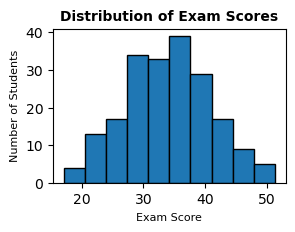

In [7]:
plt.figure(figsize=(3, 2))
plt.hist(df["exam_score"], edgecolor="black")
plt.title("Distribution of Exam Scores", fontsize=10, fontweight="bold")
plt.xlabel("Exam Score", fontsize=8)
plt.ylabel("Number of Students", fontsize=8)
plt.show()

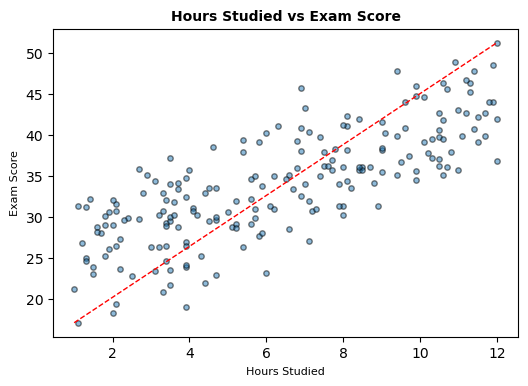

In [23]:
plt.figure(figsize=(6, 4))
plt.scatter(df["hours_studied"], df["exam_score"], edgecolor="black", alpha=0.5, s=15)

plt.plot([df["hours_studied"].min(), df["hours_studied"].max()], 
         [df["exam_score"].min(), df["exam_score"].max()], 
         color="red", linewidth=1, linestyle="--")

plt.title("Hours Studied vs Exam Score", fontsize=10, fontweight="bold")
plt.xlabel("Hours Studied", fontsize=8)
plt.ylabel("Exam Score", fontsize=8)
plt.show()

In [9]:
X = df[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']]
y = df['exam_score']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 4)
(40, 4)
(160,)
(40,)


In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({"Actual scores": y_test.round(2), "Predicted scores": y_pred.round(2)})
comparison.head()

,Actual scores,Predicted scores
95,28.7,28.89
15,34.1,29.68
30,34.5,35.31
158,29.5,31.18
128,36.1,39.45


In [14]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R² Score): {r2:.4f}")

Mean Absolute Error (MAE): 2.3109
Mean Squared Error (MSE): 7.7618
Root Mean Squared Error (RMSE): 2.7860
R-squared (R² Score): 0.8537


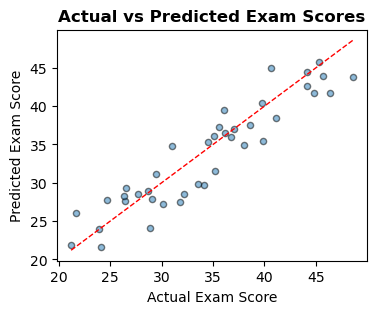

In [24]:
plt.figure(figsize=(4, 3))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor="black", s=20)
plt.plot(
    [y_test.min(), y_test.max()], 
    [y_test.min(), y_test.max()], 
    color="red", linestyle="--", linewidth=1
    )
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores", fontweight="bold")
plt.show()

In [16]:
import joblib

joblib.dump(model, "C:\\Users\\newbl\\OneDrive\\Desktop\\Exam score predictor\\models\\exam_score_predictor.pkl")

['C:\\Users\\newbl\\OneDrive\\Desktop\\Exam score predictor\\models\\exam_score_predictor.pkl']

In [17]:
new_student = pd.DataFrame({
    "hours_studied": [8],
    "sleep_hours": [7],
    "attendance_percent": [90],
    "previous_scores": [80]
})
prediction = model.predict(new_student)
print(f"Predicted Exam Score: {prediction[0]:.2f}")

Predicted Exam Score: 40.83


In [18]:
new_student = pd.DataFrame({
    "hours_studied": [3],
    "sleep_hours": [5],
    "attendance_percent": [75],
    "previous_scores": [60]
})
prediction = model.predict(new_student)
print(f"Predicted Exam Score: {prediction[0]:.2f}")

Predicted Exam Score: 26.02
